
# Поиск пластин по угловым реперным точкам ArUco

Алгоритм рассчитан на установленную схему маркеров:

| Тип кассеты | допустимые ID |
|---|---|
| 100 мм | 10–13 |
| 150 мм | 20–23 |
| 200 мм | 30–33 |

Десятки ID кодируют тип кассеты. Расположение углов определяется **геометрически**, поэтому метки не требуется переклеивать, если их ID оказались переставлены по углам.

Поток обработки:

1. обнаружить четыре ArUco;
2. определить тип кассеты;
3. выбрать внутренний угол каждой метки;
4. выполнить перспективную нормализацию;
5. искать передние кромки пластин в фиксированной зоне;
6. при наличии модели полной кассеты сопоставить кромки 25 слотам и построить карту занятости.


In [9]:
from dataclasses import dataclass
from pathlib import Path
from typing import Optional
import json
import time

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    classification_report,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

IMAGE_PATH = Path("IMG_3645.JPG")
if not IMAGE_PATH.exists():
    fallback = Path("/mnt/data/IMG_3645.JPG")
    if fallback.exists():
        IMAGE_PATH = fallback

OUTPUT_DIR = Path("/mnt/data/fiducial_plate_logreg_simplified/demo_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_VISIBLE_PLATES: Optional[int] = 5
DEFAULT_CANONICAL_SIZE = (1000, 1500)
DEFAULT_INSPECTION_ROI = (0.08, 0.01, 0.92, 0.98)
ARUCO_DICTIONARY = cv2.aruco.DICT_5X5_100

TYPE_FROM_TENS = {1: 100, 2: 150, 3: 200}
FIDUCIAL_POSITIONS = ("TL", "TR", "BR", "BL")
MARKER_GEOMETRY_POSITIONS = ("TL", "TR", "BL", "BR")

## 1. Поиск реперных точек

In [10]:
@dataclass
class FiducialDetection:
    cassette_type_mm: int
    marker_ids: list[int]
    source_points: np.ndarray
    marker_centers: dict[str, np.ndarray]
    fiducial_points: dict[str, np.ndarray]
    corners: list[np.ndarray]


def polygon_area(points: np.ndarray) -> float:
    return float(cv2.contourArea(np.asarray(points, dtype=np.float32)))


def detect_fiducials(image: np.ndarray) -> FiducialDetection:
    """Ищет четыре кассетных ArUco и возвращает внутренние угловые точки."""
    parameters = cv2.aruco.DetectorParameters()
    parameters.cornerRefinementMethod = cv2.aruco.CORNER_REFINE_SUBPIX
    detector = cv2.aruco.ArucoDetector(
        cv2.aruco.getPredefinedDictionary(ARUCO_DICTIONARY),
        parameters,
    )

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    corners, ids, _ = detector.detectMarkers(gray)
    if ids is None:
        raise RuntimeError("ArUco-метки не обнаружены.")

    markers_by_type: dict[int, list[dict]] = {}
    for marker_corners, marker_id in zip(corners, ids.ravel()):
        marker_id = int(marker_id)
        type_code = marker_id // 10
        if type_code not in TYPE_FROM_TENS:
            continue

        points = marker_corners.reshape(4, 2).astype(np.float32)
        cassette_type = TYPE_FROM_TENS[type_code]
        markers_by_type.setdefault(cassette_type, []).append(
            {
                "id": marker_id,
                "corners": points,
                "center": points.mean(axis=0),
            }
        )

    valid_groups = {
        cassette_type: markers
        for cassette_type, markers in markers_by_type.items()
        if len(markers) >= 4
    }
    if not valid_groups:
        counts = {
            cassette_type: len(markers)
            for cassette_type, markers in markers_by_type.items()
        }
        raise RuntimeError(
            "Нужно четыре репера одного типа. "
            f"Обнаружено по типам: {counts}"
        )

    cassette_type = max(valid_groups, key=lambda key: len(valid_groups[key]))
    markers = valid_groups[cassette_type]

    if len(markers) > 4:
        markers = sorted(
            markers,
            key=lambda item: polygon_area(
                np.array(
                    [
                        candidate["center"]
                        for candidate in markers
                        if candidate is not item
                    ][:4],
                    dtype=np.float32,
                )
            ),
            reverse=True,
        )[:4]

    markers_by_y = sorted(markers, key=lambda item: float(item["center"][1]))
    top = sorted(markers_by_y[:2], key=lambda item: float(item["center"][0]))
    bottom = sorted(markers_by_y[2:], key=lambda item: float(item["center"][0]))
    positioned = {
        "TL": top[0],
        "TR": top[1],
        "BL": bottom[0],
        "BR": bottom[1],
    }

    cassette_center = np.mean(
        [marker["center"] for marker in positioned.values()],
        axis=0,
    )
    fiducial_points = {}
    for position, marker in positioned.items():
        distances = np.linalg.norm(marker["corners"] - cassette_center, axis=1)
        fiducial_points[position] = marker["corners"][int(np.argmin(distances))]

    source_points = np.array(
        [fiducial_points[position] for position in FIDUCIAL_POSITIONS],
        dtype=np.float32,
    )
    minimum_area = 0.03 * image.shape[0] * image.shape[1]
    if polygon_area(source_points) < minimum_area:
        raise RuntimeError("Реперы образуют слишком маленькую область.")

    return FiducialDetection(
        cassette_type_mm=cassette_type,
        marker_ids=[positioned[position]["id"] for position in FIDUCIAL_POSITIONS],
        source_points=source_points,
        marker_centers={
            position: marker["center"]
            for position, marker in positioned.items()
        },
        fiducial_points=fiducial_points,
        corners=[marker["corners"] for marker in positioned.values()],
    )


def normalize_by_fiducials(
    image: np.ndarray,
    detection: FiducialDetection,
    canonical_size: tuple[int, int] = DEFAULT_CANONICAL_SIZE,
):
    width, height = canonical_size
    destination = np.array(
        [
            [0, 0],
            [width - 1, 0],
            [width - 1, height - 1],
            [0, height - 1],
        ],
        dtype=np.float32,
    )
    homography = cv2.getPerspectiveTransform(
        detection.source_points,
        destination,
    )
    normalized = cv2.warpPerspective(image, homography, canonical_size)
    return normalized, homography, np.linalg.inv(homography)


def draw_fiducials(
    image: np.ndarray,
    detection: FiducialDetection,
) -> np.ndarray:
    result = image.copy()

    for position in FIDUCIAL_POSITIONS:
        point = tuple(
            np.rint(detection.fiducial_points[position]).astype(int)
        )
        center = tuple(
            np.rint(detection.marker_centers[position]).astype(int)
        )
        cv2.circle(result, point, 12, (0, 0, 255), -1)
        cv2.line(result, center, point, (0, 255, 0), 3)
        cv2.putText(
            result,
            position,
            (point[0] + 10, point[1] - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 255),
            2,
            cv2.LINE_AA,
        )

    polygon = np.rint(detection.source_points).astype(np.int32)
    cv2.polylines(result, [polygon], True, (255, 0, 0), 4, cv2.LINE_AA)
    return result

## 2. Поиск передних кромок пластин

In [11]:
@dataclass
class EdgeDetectionResult:
    curves: list[np.ndarray]
    seed_rows: np.ndarray
    scores: np.ndarray
    roi_pixels: tuple[int, int, int, int]
    response: np.ndarray
    profile: np.ndarray


def roi_to_pixels(
    image_shape,
    roi_normalized: tuple[float, float, float, float],
):
    height, width = image_shape[:2]
    x1_normalized, y1_normalized, x2_normalized, y2_normalized = roi_normalized

    x1 = int(np.clip(round(x1_normalized * width), 0, width - 1))
    x2 = int(np.clip(round(x2_normalized * width), x1 + 1, width))
    y1 = int(np.clip(round(y1_normalized * height), 0, height - 1))
    y2 = int(np.clip(round(y2_normalized * height), y1 + 1, height))
    return x1, y1, x2, y2


def _vertical_gradient(crop: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8),
    ).apply(gray)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    return cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)


def build_edge_response(crop: np.ndarray):
    """Усиливает горизонтальные кромки независимо от их полярности."""
    response = np.abs(_vertical_gradient(crop))
    return cv2.GaussianBlur(response, (9, 3), 0)


def select_regular_peaks(
    peaks: np.ndarray,
    strengths: np.ndarray,
    expected_count: Optional[int],
) -> np.ndarray:
    """Выбирает последовательность приблизительно равномерных кромок."""
    if len(peaks) == 0:
        return np.array([], dtype=np.int32)

    if expected_count is None:
        cutoff = max(3.0, float(np.percentile(strengths, 45)))
        return np.sort(peaks[strengths >= cutoff].astype(np.int32))

    if len(peaks) < expected_count:
        raise RuntimeError(
            f"Найдено только {len(peaks)} кандидатов, "
            f"ожидалось {expected_count}."
        )

    best_sequence = None
    best_score = -np.inf

    for start in range(len(peaks)):
        sequences = [([start], 0.0)]

        for _ in range(1, expected_count):
            expanded = []

            for indices, _ in sequences:
                for next_index in range(indices[-1] + 1, len(peaks)):
                    new_indices = indices + [next_index]
                    selected_peaks = peaks[new_indices]

                    if len(selected_peaks) >= 3:
                        gaps = np.diff(selected_peaks)
                        gap_variation = np.std(gaps) / (np.median(gaps) + 1e-6)
                        if gap_variation > 0.35:
                            continue

                    spacing_penalty = 0.0
                    if len(selected_peaks) >= 3:
                        spacing_penalty = 7.0 * np.std(np.diff(selected_peaks))

                    score = float(
                        np.sum(strengths[new_indices]) - spacing_penalty
                    )
                    expanded.append((new_indices, score))

            if not expanded:
                sequences = []
                break

            sequences = sorted(
                expanded,
                key=lambda item: item[1],
                reverse=True,
            )[:100]

        for indices, score in sequences:
            if len(indices) == expected_count and score > best_score:
                best_sequence = indices
                best_score = score

    if best_sequence is None:
        strongest = np.argsort(strengths)[-expected_count:]
        return np.sort(peaks[strongest].astype(np.int32))

    return peaks[best_sequence].astype(np.int32)


def track_edge_curve(
    response: np.ndarray,
    seed_y: int,
    search_radius: int = 12,
) -> tuple[np.ndarray, np.ndarray]:
    """Отслеживает одну изогнутую кромку от центра в обе стороны."""
    height, width = response.shape
    center_x = width // 2

    curve = np.full(width, np.nan, dtype=np.float32)
    strengths = np.zeros(width, dtype=np.float32)
    curve[center_x] = seed_y
    strengths[center_x] = response[seed_y, center_x]

    for direction in (-1, 1):
        if direction < 0:
            x_values = range(center_x - 1, -1, -1)
        else:
            x_values = range(center_x + 1, width)

        previous_y = float(seed_y)
        velocity = 0.0

        for x in x_values:
            predicted_y = previous_y + velocity
            top = max(0, int(round(predicted_y)) - search_radius)
            bottom = min(
                height,
                int(round(predicted_y)) + search_radius + 1,
            )
            candidates = np.arange(top, bottom)

            if len(candidates) == 0:
                curve[x] = previous_y
                continue

            local_response = response[candidates, x]
            penalty = 0.20 * np.abs(candidates - predicted_y)
            best_index = int(np.argmax(local_response - penalty))
            best_y = float(candidates[best_index])

            curve[x] = best_y
            strengths[x] = float(local_response[best_index])
            velocity = 0.85 * velocity + 0.15 * (best_y - previous_y)
            previous_y = best_y

    curve = cv2.GaussianBlur(curve.reshape(1, -1), (31, 1), 0).ravel()
    return curve, strengths


def detect_visible_front_edges(
    normalized: np.ndarray,
    roi_normalized=DEFAULT_INSPECTION_ROI,
    expected_count: Optional[int] = None,
) -> EdgeDetectionResult:
    x1, y1, x2, y2 = roi_to_pixels(normalized.shape, roi_normalized)
    response = build_edge_response(normalized[y1:y2, x1:x2])

    width = response.shape[1]
    profile = np.percentile(
        response[:, int(0.10 * width):int(0.90 * width)],
        72,
        axis=1,
    )
    profile = cv2.GaussianBlur(
        profile.reshape(-1, 1).astype(np.float32),
        (1, 11),
        0,
    ).ravel()

    median = float(np.median(profile))
    mad = float(
        1.4826 * np.median(np.abs(profile - median)) + 1e-6
    )
    minimum_distance = max(12, int(response.shape[0] / 30))

    peaks, properties = find_peaks(
        profile,
        distance=minimum_distance,
        prominence=max(2.5, 1.6 * mad),
    )
    strengths = properties["prominences"].astype(np.float32)
    selected = select_regular_peaks(peaks, strengths, expected_count)

    curves = []
    curve_scores = []
    search_radius = max(8, minimum_distance // 3)

    for seed_y in selected:
        curve, local_strengths = track_edge_curve(
            response,
            int(seed_y),
            search_radius=search_radius,
        )
        curves.append(curve)
        curve_scores.append(
            float(np.percentile(local_strengths[local_strengths > 0], 50))
        )

    order = np.argsort(selected)
    return EdgeDetectionResult(
        curves=[curves[index] for index in order],
        seed_rows=selected[order],
        scores=np.asarray(curve_scores)[order],
        roi_pixels=(x1, y1, x2, y2),
        response=response,
        profile=profile,
    )


def draw_edge_detection(
    normalized: np.ndarray,
    detection: EdgeDetectionResult,
) -> np.ndarray:
    result = normalized.copy()
    x1, y1, x2, y2 = detection.roi_pixels
    colors = [
        (0, 0, 255),
        (0, 150, 255),
        (0, 220, 220),
        (0, 180, 0),
        (255, 130, 0),
        (255, 0, 255),
    ]

    for index, curve in enumerate(detection.curves):
        points = np.column_stack(
            (np.arange(len(curve)) + x1, curve + y1)
        ).round().astype(np.int32)
        color = colors[index % len(colors)]

        cv2.polylines(result, [points], False, color, 4, cv2.LINE_AA)

        label_point = points[int(0.88 * len(points))]
        cv2.circle(result, tuple(label_point), 18, color, -1, cv2.LINE_AA)
        cv2.putText(
            result,
            str(index + 1),
            (int(label_point[0] - 6), int(label_point[1] + 7)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

    cv2.rectangle(result, (x1, y1), (x2 - 1, y2 - 1), (255, 0, 0), 2)
    return result

## 3. Модель полной кассеты и карта слотов

In [12]:
def curves_to_normalized(
    curves: list[np.ndarray],
    roi_pixels: tuple[int, int, int, int],
    normalized_shape,
) -> list[list[float]]:
    """Переводит Y-кривые ROI в доли высоты нормализованного кадра."""
    _, y1, _, _ = roi_pixels
    height = normalized_shape[0]
    return [
        ((curve + y1) / height).astype(float).tolist()
        for curve in curves
    ]


def save_full_cassette_model(
    image: np.ndarray,
    path: str | Path,
    inspection_roi=DEFAULT_INSPECTION_ROI,
    slot_count: int = 25,
):
    """Создаёт геометрическую модель по полностью заполненной кассете."""
    fiducials = detect_fiducials(image)
    normalized, _, _ = normalize_by_fiducials(image, fiducials)
    edges = detect_visible_front_edges(
        normalized,
        roi_normalized=inspection_roi,
        expected_count=slot_count,
    )

    model = {
        "cassette_type_mm": fiducials.cassette_type_mm,
        "canonical_size": list(DEFAULT_CANONICAL_SIZE),
        "inspection_roi_normalized": list(inspection_roi),
        "slot_count": slot_count,
        "slot_curves_normalized": curves_to_normalized(
            edges.curves,
            edges.roi_pixels,
            normalized.shape,
        ),
        "minimum_coverage": 0.45,
    }

    Path(path).write_text(
        json.dumps(model, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    return model, normalized, edges


def load_model(path: str | Path) -> dict:
    return json.loads(Path(path).read_text(encoding="utf-8"))


def inspect_slots_with_model(
    image: np.ndarray,
    model: dict,
    search_radius: int = 10,
):
    """Проверяет каждый номинальный слот по полной эталонной кривой."""
    fiducials = detect_fiducials(image)
    if fiducials.cassette_type_mm != int(model["cassette_type_mm"]):
        raise RuntimeError("Тип кассеты не соответствует модели.")

    normalized, homography, inverse = normalize_by_fiducials(
        image,
        fiducials,
        canonical_size=tuple(model["canonical_size"]),
    )

    roi = tuple(model["inspection_roi_normalized"])
    x1, y1, x2, y2 = roi_to_pixels(normalized.shape, roi)
    response = build_edge_response(normalized[y1:y2, x1:x2])

    full_height = normalized.shape[0]
    roi_width = x2 - x1
    threshold = model.get("occupied_score_threshold")
    minimum_coverage = model.get("minimum_coverage", 0.55)

    response_median = np.median(response)
    local_noise = float(
        response_median
        + 1.4826 * np.median(np.abs(response - response_median))
    )

    slot_results = []
    for slot_index, normalized_curve in enumerate(
        model["slot_curves_normalized"]
    ):
        nominal_full_y = (
            np.asarray(normalized_curve, dtype=np.float32) * full_height
        )
        if len(nominal_full_y) != roi_width:
            nominal_full_y = np.interp(
                np.linspace(0, 1, roi_width),
                np.linspace(0, 1, len(nominal_full_y)),
                nominal_full_y,
            )

        nominal_roi_y = nominal_full_y - y1
        strengths = np.zeros(roi_width, dtype=np.float32)
        detected_y = np.zeros(roi_width, dtype=np.float32)

        for x in range(roi_width):
            center_y = int(round(nominal_roi_y[x]))
            top = max(0, center_y - search_radius)
            bottom = min(
                response.shape[0],
                center_y + search_radius + 1,
            )

            if top >= bottom:
                detected_y[x] = center_y
                continue

            candidates = np.arange(top, bottom)
            values = response[candidates, x]
            best = int(np.argmax(values))
            detected_y[x] = candidates[best]
            strengths[x] = values[best]

        positive_strengths = strengths[strengths > 0]
        score = 0.0
        if len(positive_strengths):
            score = float(np.percentile(positive_strengths, 55))

        coverage = float(
            np.mean(strengths > max(local_noise, 0.45 * score))
        )
        offset = float(np.median(detected_y - nominal_roi_y))

        occupied = None
        if threshold is not None:
            occupied = bool(
                score >= threshold
                and coverage >= minimum_coverage
            )

        slot_results.append(
            {
                "slot": slot_index,
                "occupied": occupied,
                "score": score,
                "coverage": coverage,
                "offset_px": offset,
            }
        )

    return {
        "cassette_type_mm": fiducials.cassette_type_mm,
        "normalized": normalized,
        "homography": homography,
        "inverse_homography": inverse,
        "slots": slot_results,
    }

## 4. Проверка на приложенном изображении

Тип кассеты: 100 мм
ID по геометрическим позициям TL/TR/BR/BL:
[12, 13, 10, 11]
Найдено передних кромок: 5
Стартовые Y внутри ROI: [978, 1044, 1098, 1155, 1207]


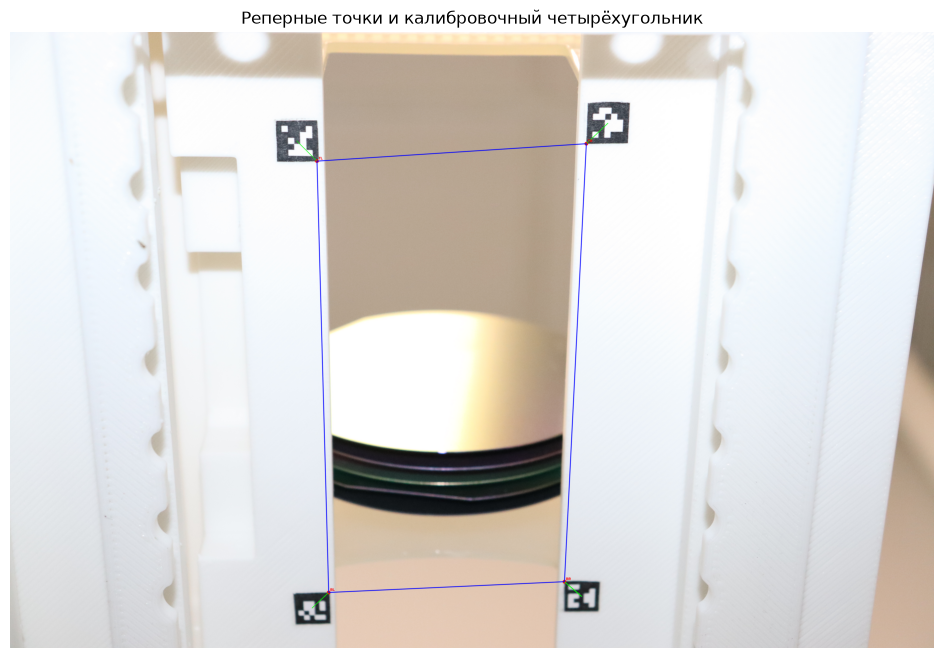

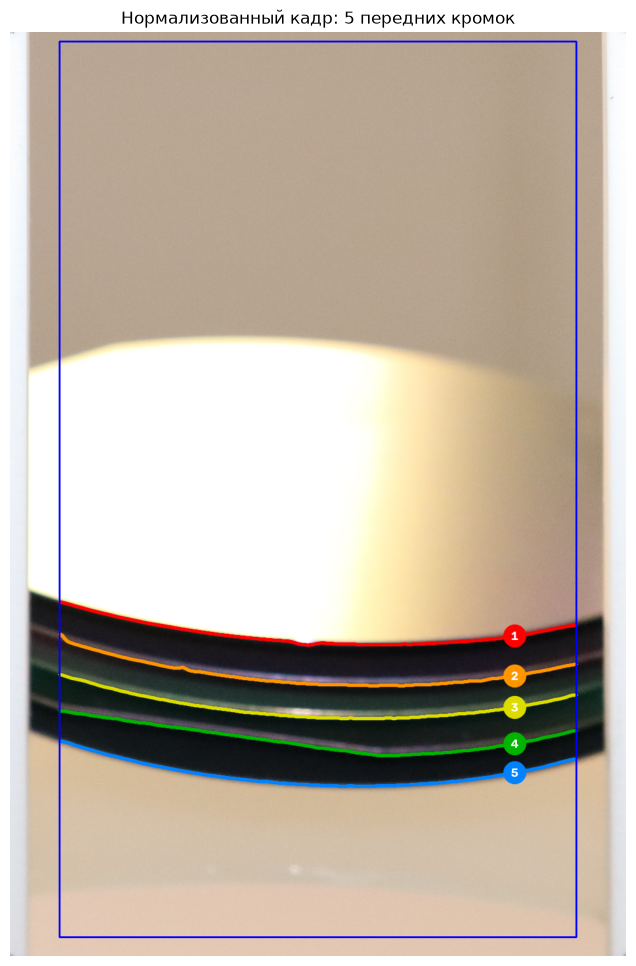

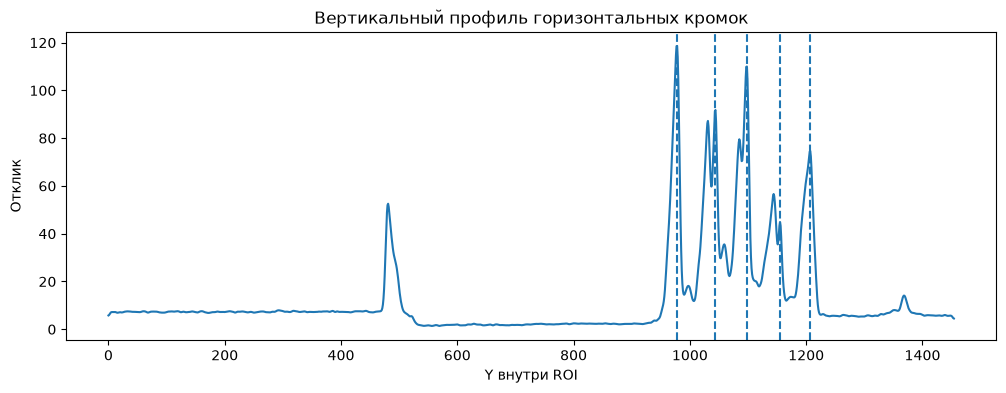

In [13]:
image = cv2.imread(str(IMAGE_PATH))
if image is None:
    raise FileNotFoundError(f"Не удалось открыть {IMAGE_PATH}")

fiducials = detect_fiducials(image)
print("Тип кассеты:", fiducials.cassette_type_mm, "мм")
print("ID по геометрическим позициям TL/TR/BR/BL:")
print(fiducials.marker_ids)

marked_fiducials = draw_fiducials(image, fiducials)
normalized, H, H_inverse = normalize_by_fiducials(image, fiducials)
edges = detect_visible_front_edges(
    normalized,
    roi_normalized=DEFAULT_INSPECTION_ROI,
    expected_count=EXPECTED_VISIBLE_PLATES,
)
marked_edges = draw_edge_detection(normalized, edges)

cv2.imwrite(str(OUTPUT_DIR / "01_fiducials.jpg"), marked_fiducials)
cv2.imwrite(str(OUTPUT_DIR / "02_normalized.jpg"), normalized)
cv2.imwrite(str(OUTPUT_DIR / "03_edges.jpg"), marked_edges)

print("Найдено передних кромок:", len(edges.curves))
print("Стартовые Y внутри ROI:", edges.seed_rows.tolist())

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(marked_fiducials, cv2.COLOR_BGR2RGB))
plt.title("Реперные точки и калибровочный четырёхугольник")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(marked_edges, cv2.COLOR_BGR2RGB))
plt.title(f"Нормализованный кадр: {len(edges.curves)} передних кромок")
plt.axis("off")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(edges.profile)
for seed in edges.seed_rows:
    plt.axvline(seed, linestyle="--")
plt.title("Вертикальный профиль горизонтальных кромок")
plt.xlabel("Y внутри ROI")
plt.ylabel("Отклик")
plt.show()